In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Machine Unlearning on CIFAR10

The goal is to deploy a toy unlearning method over MNIST, for education purposes.

# First, train a CIFAR10 classifier

### Imports

In [8]:
import torch
import torch.distributions as dist
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.utils.prune as prune

import numpy as np
import matplotlib.pyplot as plt
import copy

import torchvision
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.utils import make_grid
import psutil
import os

from datetime import datetime


%matplotlib inline

from data.dataset import cifar10_dataloaders
from trainer.utils import get_memory_footprint, get_model_weight_norm
from trainer.utils import evaluate, check_accuracy, training_regimen, full_evaluate, plot_confusion_matrix, run_inference
from models.archs.ConvNet import ConvNet

# Data

Dataset information: CIFAR-10	 45000 images for training 	 5000 images for validation	
10000 images for testing	 no normalize applied in data_transform
Training data augmentation = randomcrop(32,4) + randomhorizontalflip


/opt/miniconda3/envs/comp0081/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


X shape = torch.Size([128, 3, 32, 32])
Sample y: tensor([3, 8, 4, 1, 9, 0, 5, 4, 9, 2])


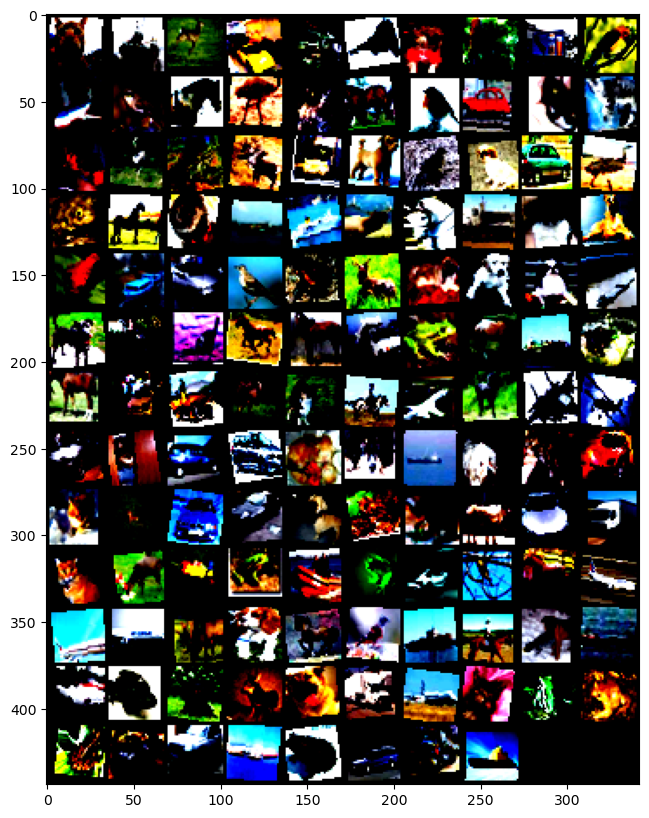

In [9]:
train_loader, val_loader, test_loader = cifar10_dataloaders(batch_size = 128, data_dir = "data/CIFAR10", num_workers = 4, no_aug = False)

# shape of data
X, y = next(iter(train_loader))
print(f'X shape = {X.shape}')
print(f"Sample y: {y[:10]}")

# visualize some photos
plt.figure(figsize=(18,10))
plt.imshow(make_grid(X, nrow=10).permute((1,2,0)));

# Train and Predict on Test

In [ ]:
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")
classifier = ConvNet().to(device)
# num_params = sum([a.numel() for a in classifier.parameters()])
# print(f"Number of model parameters: {num_params:,}")
opt = optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay = 7e-4)
criterion = nn.CrossEntropyLoss()
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2, threshold = .01, threshold_mode = "rel")
model, opt, scheduler = training_regimen(classifier, train_loader, val_loader, opt, criterion, scheduler, device, num_epochs=50, model_path = f"model_checkpoints/ConvNet_CIFAR10_{datetime.today().strftime('%Y-%m-%d')}.pth")

# Bigger evaluation on val set

In [12]:
model = ConvNet(input_dims=3, frame_size=32)
checkpoint = torch.load('models/model_checkpoints/ConvNet_CIFAR10_2026-03-17.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Successfully loaded model from epoch {checkpoint['epoch']}")
model.eval()
model.to(device)
torch.manual_seed(0)
# _, _, _ = run_inference(model, test_loader, device)

Successfully loaded model from epoch 23


# Inspecting suspicious outputs

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


tensor([[0.0000, 0.0000, 0.0050, 0.2370, 0.0430, 0.0570, 0.0030, 0.6520, 0.0000,
         0.0020],
        [0.0000, 0.0000, 0.0000, 0.8670, 0.0000, 0.1330, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0040, 0.8670, 0.0000, 0.1170, 0.0010, 0.0060, 0.0000,
         0.0050],
        [0.0000, 0.0000, 0.0010, 0.9830, 0.0060, 0.0100, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0030, 0.0000, 0.0420, 0.7870, 0.0020, 0.0450, 0.0970, 0.0000, 0.0240,
         0.0000],
        [0.0000, 0.0000, 0.0920, 0.9060, 0.0010, 0.0000, 0.0010, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.9930, 0.0000, 0.0040, 0.0030, 0.0000, 0.0000,
         0.0000],
        [0.0010, 0.0000, 0.0010, 0.8700, 0.0020, 0.1090, 0.0020, 0.0160, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.9980, 0.0000, 0.0020, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0090, 0.0230, 0.0420, 0.6530, 0.0140, 0.1740, 0.0020, 0.0820, 0.0000,
         0.0010],
        [0

tensor([7, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 9, 3])

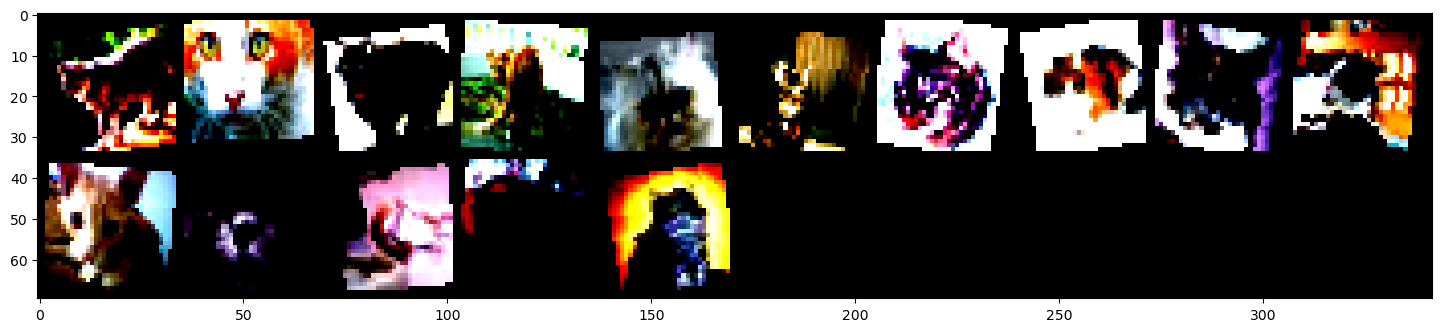

In [14]:
X, y = next(iter(train_loader))
idx_where_cat = np.argwhere(y == 3)

subset = X[idx_where_cat].squeeze()
plt.figure(figsize=(18,10))
plt.imshow(make_grid(subset, nrow=10).permute((1,2,0)));
model.cpu()
outputs = model(X[idx_where_cat].squeeze()).detach()
print(torch.round( torch.softmax(outputs, dim = 1), decimals = 3))
torch.argmax(outputs, dim = 1)